In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, r2_score, confusion_matrix, roc_curve, confusion_matrix, auc, precision_recall_curve

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import font_manager,rc
# 한글 폰트
font_location = "C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(fname=font_location).get_name()
rc('font',family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 유니코드 마이너스 기호 사용

In [2]:
# ○ (초기 실행 必) 필요 컬럼만 뺀 파일 저장(필요 시 Code cell로 변경 후 실행)

df = pd.read_csv("data/food_data_4.csv", low_memory=False)

## 필요한 컬럼만 선택
selected_cols = [
    "식품명",
    "에너지(kcal)", "탄수화물(g)", "당류(g)", "식이섬유(g)", 
    "단백질(g)", "지방(g)", "포화지방산(g)", "트랜스지방산(g)",
    "포도당(g)", "자당(g)", "과당(g)", "유당(g)",
    "칼륨(mg)", "마그네슘(mg)", "아연(mg)", "크롬(μg)",
    "비타민_D(μg)", "비타민_B1(mg)", "비타민_B2(mg)", 
    "비타민_B6(mg)", "비타민_B12(μg)", "니아신(mg)", 
    "비타민_C(mg)", "비타민_E(mg)"
]

## 실제 있는 컬럼만 추림
available_cols = [c for c in selected_cols if c in df.columns]

## 결측치를 0으로 채움
df_selected = df[available_cols].fillna(0)

## 숫자형으로 강제 변환 (문자는 NaN → 0)
for col in df_selected.columns:
    if col != "식품명":
        df_selected[col] = pd.to_numeric(df_selected[col], errors="coerce").fillna(0)

## 새 CSV로 저장
output_path = "data/food_data_glucose_selected.csv"
df_selected.to_csv(output_path, index=False, encoding="utf-8-sig")

print("저장 완료:", output_path, "행 수:", len(df_selected))

저장 완료: data/food_data_glucose_selected.csv 행 수: 167337


In [3]:
df = pd.read_csv("data/food_data_glucose_selected.csv", low_memory=False)

print("컬럼명 : ", df.columns.tolist())
print("컬럼 개수 : ", len(df.columns))
print("컬럼 키워드 일치 : ", [col for col in df.columns if "에너지" in col or "탄수화물" in col or "당류" in col])

컬럼명 :  ['식품명', '에너지(kcal)', '탄수화물(g)', '당류(g)', '식이섬유(g)', '단백질(g)', '지방(g)', '포화지방산(g)', '트랜스지방산(g)', '포도당(g)', '자당(g)', '과당(g)', '유당(g)', '칼륨(mg)', '마그네슘(mg)', '아연(mg)', '크롬(μg)', '비타민_D(μg)', '비타민_B1(mg)', '비타민_B2(mg)', '비타민_B6(mg)', '비타민_B12(μg)', '니아신(mg)', '비타민_C(mg)', '비타민_E(mg)']
컬럼 개수 :  25
컬럼 키워드 일치 :  ['에너지(kcal)', '탄수화물(g)', '당류(g)']


# 데이터 품질 시각화

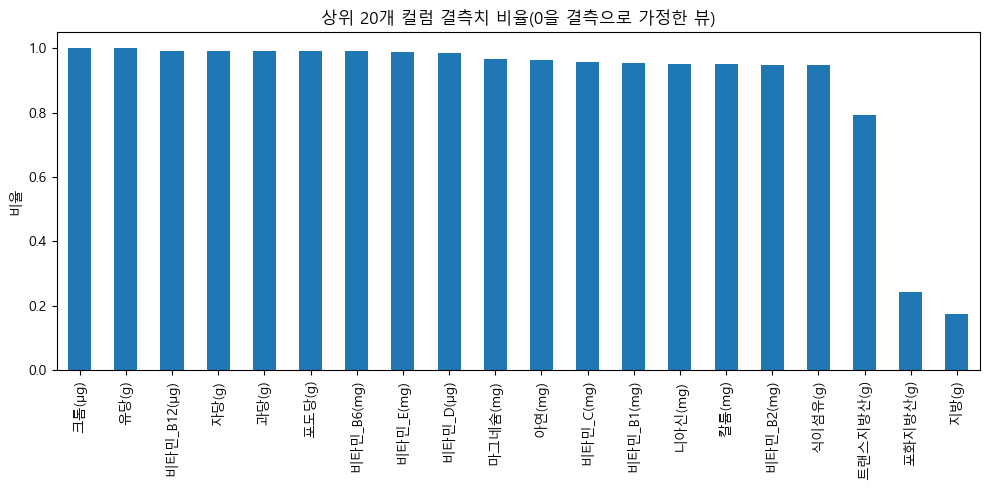

In [27]:
# 결측치 비율 막대그래프 (상위 20개)
miss = (df[selected_cols].replace(0, np.nan).isna().mean()).sort_values(ascending=False)
plt.figure(figsize=(10,5))
miss.head(20).plot(kind="bar")
plt.title("상위 20개 컬럼 결측치 비율(0을 결측으로 가정한 뷰)")
plt.ylabel("비율")
plt.tight_layout()
plt.show()

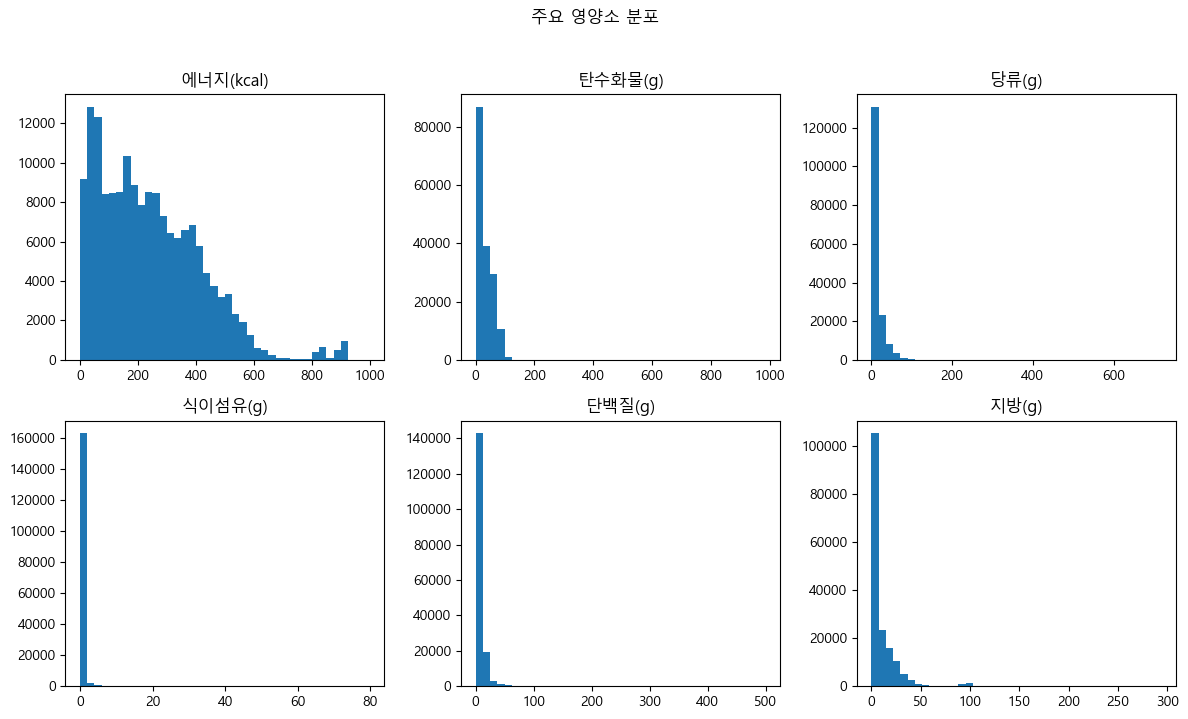

In [28]:
# 2-2. 주요 영양소 분포 (히스토그램)
cols = ["에너지(kcal)", "탄수화물(g)", "당류(g)", "식이섬유(g)", "단백질(g)", "지방(g)"]
fig, axes = plt.subplots(2, 3, figsize=(12,7))
axes = axes.ravel()
for i, c in enumerate(cols):
    x = df[c].astype(float)
    axes[i].hist(x, bins=40)
    axes[i].set_title(c)
fig.suptitle("주요 영양소 분포", y=1.02)
plt.tight_layout()
plt.show()

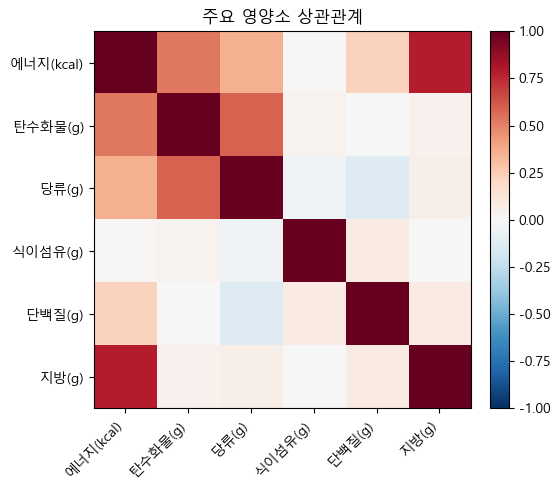

In [29]:
# 2-3. 상관관계 히트맵 (matplotlib)
macros = ["에너지(kcal)","탄수화물(g)","당류(g)","식이섬유(g)","단백질(g)","지방(g)"]
corr = df[macros].corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(macros))); ax.set_yticks(range(len(macros)))
ax.set_xticklabels(macros, rotation=45, ha="right"); ax.set_yticklabels(macros)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("주요 영양소 상관관계")
plt.tight_layout()
plt.show()

In [4]:
features = ["에너지(kcal)", "탄수화물(g)", "당류(g)", "식이섬유(g)", "단백질(g)", "지방(g)"]

df_filtered = df[features].fillna(0)

# 분류 기준: 탄수화물 30g 이상이면 1(고탄수), 아니면 0(저탄수)
X = df_filtered.drop("탄수화물(g)", axis=1)
y = (df_filtered["탄수화물(g)"] >= 30).astype(int)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 로지스틱 회귀 학습
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 예측
y_pred = log_reg.predict(X_test_scaled)

# 평가
acc = accuracy_score(y_test, y_pred)
print("로지스틱 회귀 정확도:", acc)
print("\n분류 리포트:\n", classification_report(y_test, y_pred))

로지스틱 회귀 정확도: 0.9174136488586112

분류 리포트:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     19511
           1       0.92      0.88      0.90     13957

    accuracy                           0.92     33468
   macro avg       0.92      0.91      0.91     33468
weighted avg       0.92      0.92      0.92     33468



In [5]:
# feature / target 정의
X = df[["에너지(kcal)", "당류(g)", "식이섬유(g)", "단백질(g)", "지방(g)"]]
y = df["탄수화물(g)"]

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 선형 회귀 모델
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# 예측
y_pred = lin_reg.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("선형 회귀 MSE:", mse)
print("설명력 R²:", r2)

# 회귀계수 출력
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\n회귀계수:\n", coef_df)

선형 회귀 MSE: 208.3389116130062
설명력 R²: 0.7025784883494027

회귀계수:
      Feature  Coefficient
4      지방(g)    -1.564973
2    식이섬유(g)     0.685063
3     단백질(g)    -0.576067
1      당류(g)     0.338506
0  에너지(kcal)     0.182881


In [6]:
# 사용할 feature (선형 회귀 영향도 반영)
features = ["에너지(kcal)", "당류(g)", "식이섬유(g)", "단백질(g)", "지방(g)"]

# 결측치 처리
df_filtered = df[features + ["탄수화물(g)"]].fillna(0)

# ===========================
# 2. Feature / Target 정의
# ===========================
X = df_filtered[features]
y = (df_filtered["탄수화물(g)"] >= 30).astype(int)  # 기준: 30g 이상이면 고탄수(1)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===========================
# 3. 데이터 표준화
# ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===========================
# 4. 로지스틱 회귀 모델 학습
# ===========================
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 예측
y_pred = log_reg.predict(X_test_scaled)

# ===========================
# 5. 성능 평가
# ===========================
acc = accuracy_score(y_test, y_pred)
print("로지스틱 회귀 정확도:", acc)

print("\n분류 리포트:\n", classification_report(y_test, y_pred))

print("\n혼동 행렬:\n", confusion_matrix(y_test, y_pred))

# ===========================
# 6. 회귀계수 확인
# ===========================
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\n회귀계수 (영향력):\n", coef_df)

로지스틱 회귀 정확도: 0.9154416158718777

분류 리포트:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93     19571
           1       0.91      0.88      0.90     13897

    accuracy                           0.92     33468
   macro avg       0.91      0.91      0.91     33468
weighted avg       0.92      0.92      0.92     33468


혼동 행렬:
 [[18379  1192]
 [ 1638 12259]]

회귀계수 (영향력):
      Feature  Coefficient
0  에너지(kcal)     5.331989
4      지방(g)    -3.683370
3     단백질(g)    -0.918282
1      당류(g)     0.836616
2    식이섬유(g)     0.199050


# [혈당 관리 점수(GIS)란?]

- 어떤 음식이 혈당 관리에 "유리한지/불리한지" 한눈에 볼 수 있도록 만든 종합 점수예요.
- 숫자가 낮을수록 혈당 관리에 유리(RECOMMENDED), 높을수록 불리(WORST)합니다.

[점수를 만드는 방법(간단 설명)]

1) 혈당을 빨리 올리는 요소는 더해요.
   - 탄수화물, 당류(설탕류), 포도당/자당/과당/유당, 총열량(칼로리)

2) 혈당 상승을 완화하는 요소는 빼요.
   - 식이섬유, 단백질

3) 장기적으로 도움이 되는 영양소는 빼요(점수 낮춰 줌).
   - 마그네슘, 칼륨, 아연, 크롬, 비타민 D·B군·C·E

4) 장기적으로 부담이 큰 지방은 더해요(점수 올림).
   - 포화지방, 트랜스지방

5) 서로 단위가 다른 숫자들은 0~1 사이로 맞춘 다음, 위 원칙대로 더하고 빼서 최종 점수를 만들어요.
   - 이렇게 하면 어떤 음식이든 공정하게 비교할 수 있어요.

[점수 해석]

- 점수는 0~100으로 보정합니다.
- RECOMMENDED: 하위 20% (점수가 낮음)
- OK: 중간 60%
- WORST: 상위 20% (점수가 높음)

[예시 해석 문장]

- “A음식: 점수 72 (WORST) — 당류·칼로리↑, 포화지방↑ / 식이섬유·단백질↓”
- “B음식: 점수 28 (RECOMMENDED) — 식이섬유·단백질↑, 당류↓”
- “관리 팁: 식사 후 15분 걷기, 물 충분히 마시기”


# 기존 자료에서 음식명과 공식만 있는 파일 형태(필요 시 Code cell로 변경 후 실행)

## 1) 안전 전처리
cols = ['에너지(kcal)','탄수화물(g)','당류(g)','식이섬유(g)','단백질(g)','지방(g)',
        '포화지방산(g)','트랜스지방산(g)','포도당(g)','자당(g)','과당(g)','유당(g)',
        '칼륨(mg)','마그네슘(mg)','아연(mg)','크롬(μg)',
        '비타민_D(μg)','비타민_B1(mg)','비타민_B2(mg)',
        '비타민_B6(mg)','비타민_B12(μg)','니아신(mg)','비타민_C(mg)','비타민_E(mg)']
for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

## 2) Min–Max 정규화 + 클리핑
def minmax(s):
    s = s.copy()
    vmin, vmax = s.min(), s.max()
    if vmax == vmin:
        return np.zeros_like(s, dtype=float)
    x = (s - vmin) / (vmax - vmin)
    return x.clip(0,1)

N = {}
for c in cols:
    if c in df.columns:
        N[c] = minmax(df[c])
    else:
        N[c] = np.zeros(len(df))

## 3) 블록 점수
FastCarb = (0.4*N['탄수화물(g)'] + 0.4*N['당류(g)']
            + 0.05*N['포도당(g)'] + 0.05*N['자당(g)']
            + 0.05*N['과당(g)'] + 0.05*N['유당(g)'])

Load = 0.3*N['에너지(kcal)'] + FastCarb

Buffer = 0.6*N['식이섬유(g)'] + 0.4*N['단백질(g)']

Minerals = (0.5*N['마그네슘(mg)'] + 0.3*N['칼륨(mg)']
            + 0.1*N['아연(mg)'] + 0.1*N['크롬(μg)'])

FatsRisk = 0.7*N['포화지방산(g)'] + 0.3*N['트랜스지방산(g)']

Bsum = (N['비타민_B1(mg)'] + N['비타민_B2(mg)'] + N['비타민_B6(mg)']
        + N['비타민_B12(μg)'] + N['니아신(mg)']) / 5.0
Vitamins = 0.4*N['비타민_D(μg)'] + 0.2*Bsum + 0.2*N['비타민_C(mg)'] + 0.2*N['비타민_E(mg)']

## 4) 최종 GIS (0~100 스케일 권장)
GIS_raw = (0.45*Load - 0.25*Buffer + 0.15*FatsRisk - 0.10*Minerals - 0.05*Vitamins)
GIS = minmax(pd.Series(GIS_raw)) * 100

df['GIS'] = GIS.round(2)
df['GIS_Load'] = (minmax(pd.Series(Load))*100).round(1)
df['GIS_Buffer'] = (minmax(pd.Series(Buffer))*100).round(1)
df['GIS_Fats'] = (minmax(pd.Series(FatsRisk))*100).round(1)
df['GIS_Minerals'] = (minmax(pd.Series(Minerals))*100).round(1)
df['GIS_Vitamins'] = (minmax(pd.Series(Vitamins))*100).round(1)

## 5) 등급화 (퍼센타일 기준)
p20, p80 = np.percentile(df['GIS'], [20, 80])
def label(v):
    if v <= p20: return "RECOMMENDED"
    if v >= p80: return "WORST"
    return "OK"

df['GIS_label'] = df['GIS'].apply(label)

## 저장
df_out = df[['식품명','GIS','GIS_label','GIS_Load','GIS_Buffer','GIS_Fats','GIS_Minerals','GIS_Vitamins']]
df_out.to_csv("data/food_glucose_score.csv", index=False, encoding="utf-8-sig")
print("Saved:", "data/food_glucose_score.csv", "| p20=", round(p20,1), "p80=", round(p80,1))

In [7]:
# (초기실행 必) 기존 자료 보존하며 새로운 컬럼으로 점수를 넣은 파일 형태(필요 시 Code cell로 변경 후 실행)

IN_PATH = "data/food_data_glucose_selected.csv"
OUT_PATH = "data/food_data_glucose_selected_with_scores.csv"

df = pd.read_csv(IN_PATH)

## 사용할 컬럼 목록
cols = ['에너지(kcal)','탄수화물(g)','당류(g)','식이섬유(g)','단백질(g)','지방(g)',
        '포화지방산(g)','트랜스지방산(g)','포도당(g)','자당(g)','과당(g)','유당(g)',
        '칼륨(mg)','마그네슘(mg)','아연(mg)','크롬(μg)',
        '비타민_D(μg)','비타민_B1(mg)','비타민_B2(mg)',
        '비타민_B6(mg)','비타민_B12(μg)','니아신(mg)','비타민_C(mg)','비타민_E(mg)']

## 안전 전처리: 숫자화 + 결측치 0 채움
for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    else:
        # 빠진 컬럼은 0으로 채운 가상 컬럼 추가
        df[c] = 0

## Min–Max 정규화 함수 (모든 값이 같을 때는 0으로)
def minmax(s):
    s = s.astype(float)
    vmin, vmax = s.min(), s.max()
    if vmax == vmin:
        return np.zeros_like(s, dtype=float)
    x = (s - vmin) / (vmax - vmin)
    return x.clip(0,1)

## 정규화 사전
N = {c: minmax(df[c]) for c in cols}

## 블록 점수 구성 (초기 가중치 베이스라인)
FastCarb = (0.4*N['탄수화물(g)'] + 0.4*N['당류(g)']
            + 0.05*N['포도당(g)'] + 0.05*N['자당(g)']
            + 0.05*N['과당(g)'] + 0.05*N['유당(g)'])

Load = 0.3*N['에너지(kcal)'] + FastCarb
Buffer = 0.6*N['식이섬유(g)'] + 0.4*N['단백질(g)']
Minerals = (0.5*N['마그네슘(mg)'] + 0.3*N['칼륨(mg)']
            + 0.1*N['아연(mg)'] + 0.1*N['크롬(μg)'])
FatsRisk = 0.7*N['포화지방산(g)'] + 0.3*N['트랜스지방산(g)']

Bsum = (N['비타민_B1(mg)'] + N['비타민_B2(mg)'] + N['비타민_B6(mg)']
        + N['비타민_B12(μg)'] + N['니아신(mg)']) / 5.0
Vitamins = 0.4*N['비타민_D(μg)'] + 0.2*Bsum + 0.2*N['비타민_C(mg)'] + 0.2*N['비타민_E(mg)']

## 최종 GIS 원점수 (가중합)
GIS_raw = (0.45*Load - 0.25*Buffer + 0.15*FatsRisk - 0.10*Minerals - 0.05*Vitamins)

## 0~100 보정
def scale_0_100(s):
    s = pd.Series(s, index=df.index)
    vmin, vmax = s.min(), s.max()
    if vmax == vmin:
        return pd.Series(50.0, index=df.index)  # 모두 동일하면 50 고정
    return ((s - vmin) / (vmax - vmin) * 100)

df['GIS'] = scale_0_100(GIS_raw).round(2)
df['GIS_Load'] = scale_0_100(Load).round(1)
df['GIS_Buffer'] = scale_0_100(Buffer).round(1)
df['GIS_Fats'] = scale_0_100(FatsRisk).round(1)
df['GIS_Minerals'] = scale_0_100(Minerals).round(1)
df['GIS_Vitamins'] = scale_0_100(Vitamins).round(1)

## 등급 컷(퍼센타일)
p20, p80 = np.percentile(df['GIS'], [20, 80])

def label(v):
    if v <= p20: return "RECOMMENDED"
    if v >= p80: return "WORST"
    return "OK"

df['GIS_label'] = df['GIS'].apply(label)

## 저장 (원본 보존용 새 파일명)
df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
print(f"Saved: {OUT_PATH} | p20={p20:.1f}, p80={p80:.1f}")

Saved: data/food_data_glucose_selected_with_scores.csv | p20=27.1, p80=38.9


# GIS(혈당 관리 점수) 확인용 시각화 
  - 목적: “우리가 만든 점수체계가 어떻게 분포하는지”와 “등급 컷” 명확히 시각화.

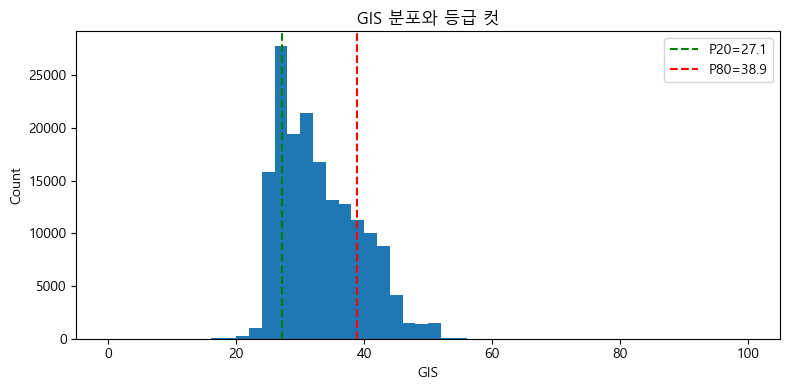

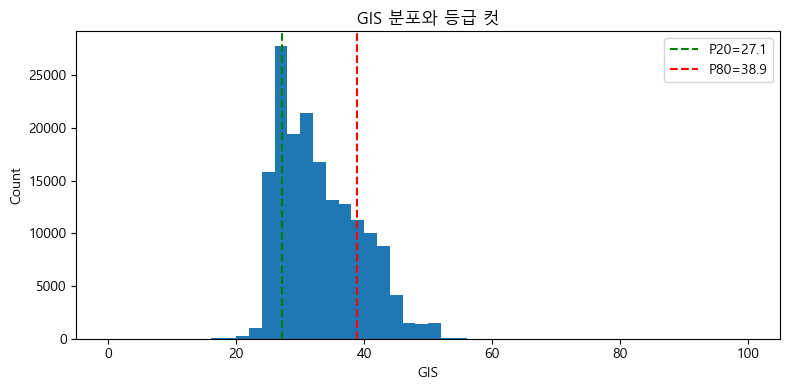

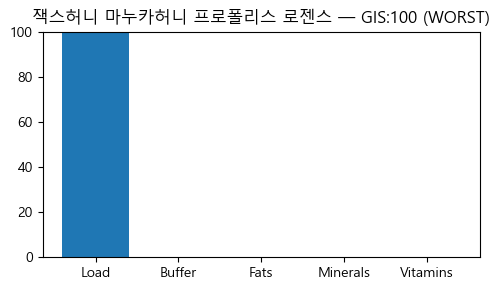

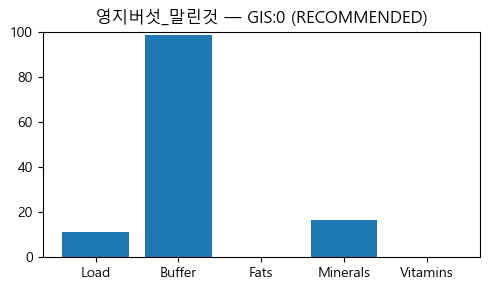

In [31]:
# 3-1. GIS 분포 + 컷라인
if "GIS" in df.columns:
    GIS = df["GIS"].astype(float).fillna(0)
    p20, p80 = np.percentile(GIS, [20, 80])

    plt.figure(figsize=(8,4))
    plt.hist(GIS, bins=50)
    plt.axvline(p20, color="g", linestyle="--", label=f"P20={p20:.1f}")
    plt.axvline(p80, color="r", linestyle="--", label=f"P80={p80:.1f}")
    plt.title("GIS 분포와 등급 컷")
    plt.xlabel("GIS"); plt.ylabel("Count")
    plt.legend(); plt.tight_layout()
    plt.show()

    # 3-2. 단건 카드(서브스코어 막대)
    subcols = ["GIS_Load","GIS_Buffer","GIS_Fats","GIS_Minerals","GIS_Vitamins"]
    if all(c in df.columns for c in subcols):
        def plot_gis_card(row):
            labs = ["Load","Buffer","Fats","Minerals","Vitamins"]
            vals = [row["GIS_Load"], row["GIS_Buffer"], row["GIS_Fats"], row["GIS_Minerals"], row["GIS_Vitamins"]]
            plt.figure(figsize=(5,3))
            plt.bar(labs, vals)
            title = f"{row.get('식품명','(식품)')} — GIS:{row['GIS']:.0f} ({row.get('GIS_label','')})"
            plt.title(title); plt.ylim(0,100); plt.tight_layout(); plt.show()

        top = df.sort_values("GIS", ascending=False).head(1).iloc[0]
        low = df.sort_values("GIS", ascending=True).head(1).iloc[0]
        plot_gis_card(top); plot_gis_card(low)

# 분류/예측 결과 그림(로지스틱)
  - 목적: 혼동행렬/ROC/PR로 “우리 모델이 어디서 잘하고, 어디서 놓치는지”를 시각적 근거로.

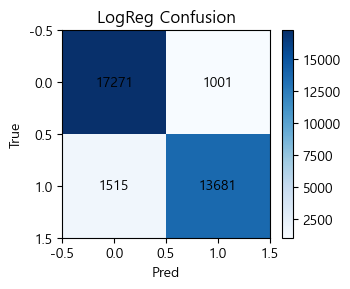

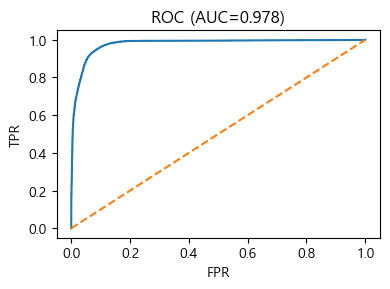

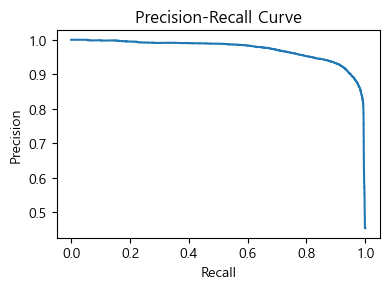

              precision    recall  f1-score   support

           0      0.919     0.945     0.932     18272
           1      0.932     0.900     0.916     15196

    accuracy                          0.925     33468
   macro avg      0.926     0.923     0.924     33468
weighted avg      0.925     0.925     0.925     33468



In [35]:
# 라벨: 예시 — 탄≥30 또는 당≥15 고위험(1)
y = ((df["탄수화물(g)"] >= 30) | (df["당류(g)"] >= 15)).astype(int)
X = df[["에너지(kcal)","당류(g)","식이섬유(g)","단백질(g)","지방(g)"]]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)

lr = LogisticRegression(max_iter=2000)
lr.fit(Xtr_s, ytr)

# 혼동행렬
pred = lr.predict(Xte_s)
cm = confusion_matrix(yte, pred)

fig, ax = plt.subplots(figsize=(4,3))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_xlabel("Pred"); ax.set_ylabel("True"); ax.set_title("LogReg Confusion")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); 
plt.show()

# ROC
prob = lr.predict_proba(Xte_s)[:,1]
fpr, tpr, thr = roc_curve(yte, prob); roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4,3))
plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
plt.title(f"ROC (AUC={roc_auc:.3f})"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.tight_layout();
plt.show()

# PR
prec, rec, thr2 = precision_recall_curve(yte, prob)
plt.figure(figsize=(4,3))
plt.plot(rec, prec)
plt.title("Precision-Recall Curve"); plt.xlabel("Recall"); plt.ylabel("Precision")
plt.tight_layout();
plt.show()

print(classification_report(yte, pred, digits=3))

In [8]:
# 데이터 로딩 (with_scores 파일이 있으면 사용)
# ----------------------------------------
SRC = Path("data/food_data_glucose_selected_with_scores.csv")
if not SRC.exists():
    # 점수 열이 없는 원본을 쓰는 경우: 먼저 원본 로드
    SRC = Path("data/food_data_glucose_selected.csv")

df = pd.read_csv(SRC, low_memory=False)

# 안전 변환
def to_num(col):
    return pd.to_numeric(df[col], errors="coerce").fillna(0)

# 라벨 정의 (정답)
# 고탄수 기준: 탄수화물 >= 30g 또는 당류 >= 15g
# ----------------------------------------
for c in ["탄수화물(g)", "당류(g)"]:
    if c not in df.columns:
        df[c] = 0
y = ((to_num("탄수화물(g)") >= 30) | (to_num("당류(g)") >= 15)).astype(int)

# Feature 세팅
#   (A) Baseline: 에너지, 당류, 식이섬유, 단백질, 지방
#   (B) GIS-Blocks: Load/Buffer/Fats/Minerals/Vitamins (+ 옵션: GIS)
# ----------------------------------------
baseline_feats = ["에너지(kcal)", "당류(g)", "식이섬유(g)", "단백질(g)", "지방(g)"]
for c in baseline_feats:
    if c not in df.columns:
        df[c] = 0

has_gis_cols = all(c in df.columns for c in
                   ["GIS_Load","GIS_Buffer","GIS_Fats","GIS_Minerals","GIS_Vitamins"])
if not has_gis_cols:
    # 점수 열이 없으면 블록 피처는 생략
    gis_block_feats = []
else:
    gis_block_feats = ["GIS_Load","GIS_Buffer","GIS_Fats","GIS_Minerals","GIS_Vitamins"]
    # 선택: GIS까지 포함해서 한 번 더 비교해보고 싶다면 주석 해제
    # gis_block_feats = ["GIS_Load","GIS_Buffer","GIS_Fats","GIS_Minerals","GIS_Vitamins","GIS"]

X_base = df[baseline_feats].apply(pd.to_numeric, errors="coerce").fillna(0)

if gis_block_feats:
    X_gis = df[gis_block_feats].apply(pd.to_numeric, errors="coerce").fillna(0)
else:
    X_gis = None

def run_logreg(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    sc = StandardScaler()
    X_train_s = sc.fit_transform(X_train)
    X_test_s = sc.transform(X_test)

    clf = LogisticRegression(max_iter=2000, n_jobs=None)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n[{name}] 정확도: {acc:.4f}")
    print("분류 리포트:\n", classification_report(y_test, y_pred, digits=3))
    print("혼동 행렬:\n", confusion_matrix(y_test, y_pred))

    coef_df = pd.DataFrame({
        "Feature": list(X.columns),
        "Coef": clf.coef_[0]
    }).assign(Abs=lambda d: d["Coef"].abs()).sort_values("Abs", ascending=False)
    print("\n피처 영향(계수 절댓값 내림차순):\n", coef_df.drop(columns="Abs"))
    return acc

# 학습/평가
# ----------------------------------------
acc_base = run_logreg(X_base, y, "Baseline(매크로5)")
if X_gis is not None and X_gis.shape[1] > 0:
    acc_gis = run_logreg(X_gis, y, "GIS-Blocks")
else:
    acc_gis = None

# 요약 출력
print("\n=== 요약 ===")
print(f"Baseline(매크로5) ACC: {acc_base:.4f}")
if acc_gis is not None:
    print(f"GIS-Blocks ACC:     {acc_gis:.4f}  (블록 점수 기반)")
else:
    print("GIS-Blocks: 점수 열이 없어 생략됨 (먼저 with_scores 파일을 생성하세요)")



[Baseline(매크로5)] 정확도: 0.9248
분류 리포트:
               precision    recall  f1-score   support

           0      0.919     0.945     0.932     18272
           1      0.932     0.900     0.916     15196

    accuracy                          0.925     33468
   macro avg      0.926     0.923     0.924     33468
weighted avg      0.925     0.925     0.925     33468

혼동 행렬:
 [[17271  1001]
 [ 1515 13681]]

피처 영향(계수 절댓값 내림차순):
      Feature      Coef
0  에너지(kcal)  5.845336
4      지방(g) -4.133144
1      당류(g)  2.871869
3     단백질(g) -1.108575
2    식이섬유(g)  0.216476

[GIS-Blocks] 정확도: 0.8767
분류 리포트:
               precision    recall  f1-score   support

           0      0.860     0.925     0.891     18272
           1      0.901     0.818     0.858     15196

    accuracy                          0.877     33468
   macro avg      0.880     0.872     0.874     33468
weighted avg      0.878     0.877     0.876     33468

혼동 행렬:
 [[16905  1367]
 [ 2761 12435]]

피처 영향(계수 절댓값 내림차순):
         Feat

## ↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑
### 원본 feature(에너지·당류·식이섬유·단백질·지방) → 블록(Load/Buffer/…)로 합쳐버리니 세밀한 패턴이 사라짐.  
### 고로 세밀 및 정답률을 높이기 위해 기존 데이터도 활용

In [9]:
# 라벨: 고탄수(또는 당류 높은 경우) → 1
y = ((pd.to_numeric(df["탄수화물(g)"], errors="coerce").fillna(0) >= 30) |
     (pd.to_numeric(df["당류(g)"], errors="coerce").fillna(0) >= 15)).astype(int)

baseline = ["에너지(kcal)","당류(g)","식이섬유(g)","단백질(g)","지방(g)"]
blocks   = ["GIS_Load","GIS_Buffer","GIS_Fats","GIS_Minerals","GIS_Vitamins"]

# 안전 숫자화
X_base = df[baseline].apply(pd.to_numeric, errors="coerce").fillna(0)
X_blk  = df[blocks].apply(pd.to_numeric, errors="coerce").fillna(0)

# 결합 Feature
X = pd.concat([X_base, X_blk], axis=1)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# train-fit 기준 표준화
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_s, y_train)

# 기본 0.5 임계값
y_pred = clf.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
print(f"[Combined] ACC={acc:.4f}")
print(classification_report(y_test, y_pred, digits=3))
print("혼동행렬:\n", confusion_matrix(y_test, y_pred))

# 임계값 튜닝 (ROC로 최적 지점 탐색: Youden's J)
y_prob = clf.predict_proba(X_test_s)[:,1]
fpr, tpr, thr = roc_curve(y_test, y_prob)
j_idx = np.argmax(tpr - fpr)
best_thr = thr[j_idx]
print("Best threshold by Youden's J:", round(best_thr, 3))

y_pred_tuned = (y_prob >= best_thr).astype(int)
print(f"[Combined@thr={best_thr:.3f}] ACC={accuracy_score(y_test, y_pred_tuned):.4f}")
print(classification_report(y_test, y_pred_tuned, digits=3))

[Combined] ACC=0.9665
              precision    recall  f1-score   support

           0      0.963     0.977     0.970     18272
           1      0.971     0.954     0.963     15196

    accuracy                          0.967     33468
   macro avg      0.967     0.966     0.966     33468
weighted avg      0.967     0.967     0.967     33468

혼동행렬:
 [[17846   426]
 [  694 14502]]
Best threshold by Youden's J: 0.392
[Combined@thr=0.392] ACC=0.9690
              precision    recall  f1-score   support

           0      0.976     0.967     0.972     18272
           1      0.961     0.972     0.966     15196

    accuracy                          0.969     33468
   macro avg      0.968     0.969     0.969     33468
weighted avg      0.969     0.969     0.969     33468



In [10]:
clf_lgbm = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=-1,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
clf_lgbm.fit(X_train, y_train)  # 트리 모델은 보통 스케일링 X

pred = clf_lgbm.predict(X_test)
print("[LGBM] ACC:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, digits=3))

[LightGBM] [Info] Number of positive: 60784, number of negative: 73085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007653 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2333
[LightGBM] [Info] Number of data points in the train set: 133869, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454056 -> initscore=-0.184297
[LightGBM] [Info] Start training from score -0.184297
[LGBM] ACC: 0.9928588502450102
              precision    recall  f1-score   support

           0      0.993     0.994     0.993     18272
           1      0.992     0.992     0.992     15196

    accuracy                          0.993     33468
   macro avg      0.993     0.993     0.993     33468
weighted avg      0.993     0.993     0.993     33468



# RECOMMENDED/WORST 리스트
  - 목적: 데모 때 바로 보여줄 수 있는 “Top 카드” — 의사결정 메시지화.

,식품명,GIS,GIS_label,에너지(kcal),탄수화물(g),당류(g),식이섬유(g),단백질(g),지방(g)
164573,영지버섯_말린것,0.000000,RECOMMENDED,187.000000,81.030000,0.000000,77.900000,9.410000,1.400000
164556,상황버섯_말린것,0.330000,RECOMMENDED,179.000000,84.580000,0.000000,74.400000,4.400000,0.270000
163803,곤약(구약나물)_분말화한것,1.120000,RECOMMENDED,194.000000,85.300000,0.000000,79.900000,3.000000,0.100000
164878,"미역류,미역,줄기,말린것",3.070000,RECOMMENDED,150.000000,43.650000,0.000000,35.600000,20.310000,4.830000
164529,느타리버섯_말린것(자연건조),3.550000,RECOMMENDED,182.000000,58.920000,0.000000,57.200000,25.360000,2.980000
79792,프레시 원두 G1,3.760000,RECOMMENDED,0.000000,0.000000,0.000000,0.000000,500.000000,0.000000
164558,석이버섯_말린것,3.770000,RECOMMENDED,165.000000,68.470000,0.330000,60.900000,11.750000,0.960000
50585,호밀깜빠뉴,5.220000,RECOMMENDED,0.000000,0.000000,0.000000,0.000000,482.000000,9.600000
112078,리너지홍삼식이섬유분#80,6.520000,RECOMMENDED,241.000000,76.600000,0.000000,69.700000,13.140000,2.350000
164528,느타리버섯_말린것,7.060000,RECOMMENDED,189.000000,60.720000,0.000000,57.200000,25.100000,3.900000


,식품명,GIS,GIS_label,에너지(kcal),탄수화물(g),당류(g),식이섬유(g),단백질(g),지방(g)
28399,잭스허니 마누카허니 프로폴리스 로젠스,100.000000,WORST,0.000000,986.400000,718.400000,0.000000,0.200000,2.800000
31547,바라기 약쑥 캔디,99.270000,WORST,0.000000,983.800000,704.300000,0.000000,1.600000,9.300000
64505,미루꾸 플랫소스(슈패너),87.670000,WORST,0.000000,724.000000,674.000000,0.000000,4.000000,4.500000
99052,갈릭소스,68.650000,WORST,683.000000,2.870000,0.620000,0.300000,1.430000,74.000000
99066,레몬소스,68.550000,WORST,671.000000,0.740000,0.770000,0.000000,0.800000,74.000000
104901,참나물장아찌,68.480000,WORST,921.000000,221.000000,187.000000,0.000000,11.000000,0.000000
104890,생취장아찌,68.480000,WORST,921.000000,221.000000,187.000000,0.000000,11.000000,0.000000
14820,초코슈,68.030000,WORST,579.000000,99.000000,36.800000,0.000000,12.800000,14.400000
91367,위더스 도라지배젤리스틱,67.680000,WORST,959.000000,216.000000,160.500000,0.000000,18.000000,2.500000
110671,식물성 멜라토닌 35.5℃,65.110000,WORST,971.000000,252.860000,69.500000,0.000000,8.250000,0.810000


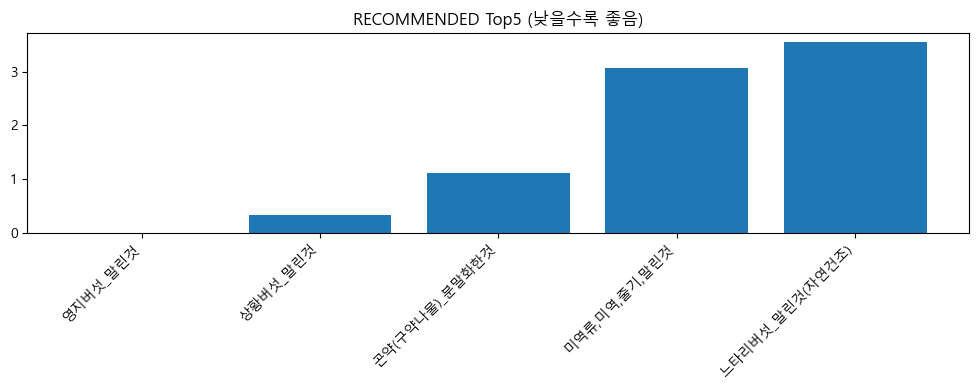

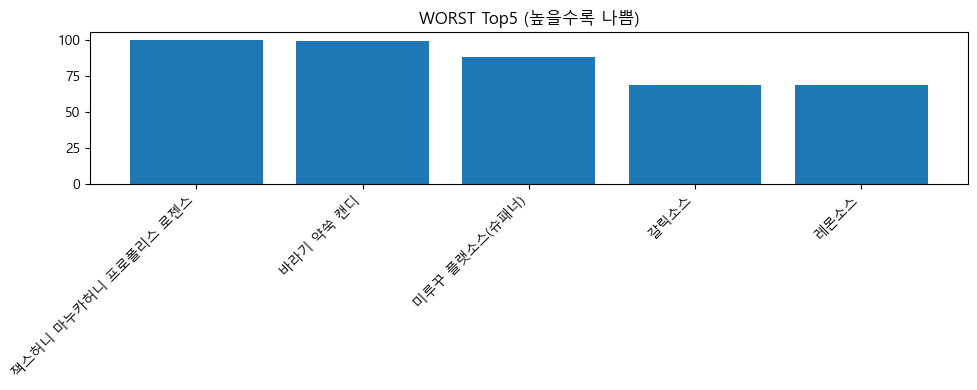

In [37]:
cols_show = ["식품명","GIS","GIS_label","에너지(kcal)","탄수화물(g)","당류(g)","식이섬유(g)","단백질(g)","지방(g)"]
if "GIS" in df.columns:
    top10 = df.sort_values("GIS", ascending=False).head(10)[cols_show]
    best10 = df.sort_values("GIS", ascending=True).head(10)[cols_show]
    display(best10.style.set_caption("RECOMMENDED Top10"))
    display(top10.style.set_caption("WORST Top10"))

    # 막대 예시
    worst5 = df.sort_values("GIS", ascending=False).head(5)
    best5  = df.sort_values("GIS", ascending=True).head(5)

    plt.figure(figsize=(10,4))
    plt.bar(best5["식품명"], best5["GIS"])
    plt.title("RECOMMENDED Top5 (낮을수록 좋음)"); plt.xticks(rotation=45, ha="right")
    plt.tight_layout();
    plt.show()

    plt.figure(figsize=(10,4))
    plt.bar(worst5["식품명"], worst5["GIS"])
    plt.title("WORST Top5 (높을수록 나쁨)"); plt.xticks(rotation=45, ha="right")
    plt.tight_layout();
    plt.show()

In [11]:
# 1) 원천 피처로부터 블록/점수/라벨을 '훈련셋에서만' fit
base_cols = ['에너지(kcal)','탄수화물(g)','당류(g)','식이섬유(g)','단백질(g)','지방(g)',
             '포화지방산(g)','트랜스지방산(g)','포도당(g)','자당(g)','과당(g)','유당(g)',
             '칼륨(mg)','마그네슘(mg)','아연(mg)','크롬(μg)','비타민_D(μg)','비타민_B1(mg)',
             '비타민_B2(mg)','비타민_B6(mg)','비타민_B12(μg)','니아신(mg)','비타민_C(mg)','비타민_E(mg)']
D = df.copy()
for c in base_cols:
    D[c] = pd.to_numeric(D[c], errors="coerce").fillna(0)

# 스플릿 먼저
X0 = D[["에너지(kcal)","당류(g)","식이섬유(g)","단백질(g)","지방(g)"]]
X0_tr, X0_te, idx_tr, idx_te = train_test_split(X0, D.index, test_size=0.2, random_state=42, stratify=df["GIS_label"].map(label_map))

# train에서만 minmax 파라미터 추정
def fit_minmax(s):
    return float(s.min()), float(s.max())

mm = {c: fit_minmax(D.loc[idx_tr, c]) for c in base_cols}
def transform_minmax(s, vmin, vmax):
    if vmax == vmin: 
        return np.zeros_like(s, dtype=float)
    x = (s - vmin) / (vmax - vmin)
    return np.clip(x, 0, 1)

# train 기준으로 블록/점수 계산 함수
def compute_blocks(idx):
    N = {}
    for c in base_cols:
        vmin, vmax = mm[c]
        N[c] = transform_minmax(D.loc[idx, c].values.astype(float), vmin, vmax)

    FastCarb = (0.4*N['탄수화물(g)'] + 0.4*N['당류(g)']
                + 0.05*N['포도당(g)'] + 0.05*N['자당(g)']
                + 0.05*N['과당(g)'] + 0.05*N['유당(g)'])
    Load = 0.3*N['에너지(kcal)'] + FastCarb
    Buffer = 0.6*N['식이섬유(g)'] + 0.4*N['단백질(g)']
    Minerals = (0.5*N['마그네슘(mg)'] + 0.3*N['칼륨(mg)'] + 0.1*N['아연(mg)'] + 0.1*N['크롬(μg)'])
    FatsRisk = 0.7*N['포화지방산(g)'] + 0.3*N['트랜스지방산(g)']
    Bsum = (N['비타민_B1(mg)'] + N['비타민_B2(mg)'] + N['비타민_B6(mg)'] + N['비타민_B12(μg)'] + N['니아신(mg)']) / 5.0
    Vitamins = 0.4*N['비타민_D(μg)'] + 0.2*Bsum + 0.2*N['비타민_C(mg)'] + 0.2*N['비타민_E(mg)']
    GIS_raw = (0.45*Load - 0.25*Buffer + 0.15*FatsRisk - 0.10*Minerals - 0.05*Vitamins)
    return GIS_raw, Load, Buffer, FatsRisk, Minerals, Vitamins

GIS_tr, *_ = compute_blocks(idx_tr)
p20, p80 = np.percentile(GIS_tr, [20, 80])

def label_by_threshold(g):
    if g <= p20: return 0
    if g >= p80: return 2
    return 1

# train/test 각각 라벨 생성 (train 기준 스케일/컷 사용)
GIS_te, *_ = compute_blocks(idx_te)
y_tr = pd.Series(GIS_tr).apply(label_by_threshold).values
y_te = pd.Series(GIS_te).apply(label_by_threshold).values

# 2) 학습은 원본 매크로 5개로 (GIS/블록 사용 금지)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_tr = X0_tr.values
X_te = X0_te.values

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

clf = LogisticRegression(max_iter=3000, multi_class="multinomial")
clf.fit(X_tr_s, y_tr)

pred = clf.predict(X_te_s)
print("ACC:", accuracy_score(y_te, pred))
print(classification_report(y_te, pred, target_names=["RECOMMENDED","OK","WORST"], digits=3))

NameError: name 'label_map' is not defined